In [1]:
import qutip as qt
from qutip import tensor, basis, qeye, Qobj
import numpy as np
from quantum_logical.trotter_diff import Trotterization
from tqdm import tqdm
from quantum_logical.state import state as st
from quantum_logical.cnot_gate_creation import cnot

# there is circular importation that needs fixed 

In [2]:
# qubit 
def repetition(values, rho, total_time):

    # cnots, T, dim, N, x_layer, correction_z, hada_layer, x_gate, hada = values # collecting experimental values 
    T, dim, N, hada, correction_z = values

    # initialize the state with ancillas 
    rho = tensor(qt.ptrace(rho, [0,1,2]), 
                 tensor(basis(dim, 0), basis(dim, 0)) * tensor(basis(dim, 0), basis(dim, 0)).dag())

    hada_layer_mod = tensor([hada] * 3)

    from quantum_logical.gate_extender import Convert_levels
    create = Convert_levels(num_qubits=N)

    cnots = [create.Cnot(dim=2, control=con, target=tar, high=1, low=0) for (con, tar) in [[0,3], [1,3], [1,4], [2,4]]]

    # if cycle_count == 0:
    gates = [[hada_layer_mod], [cnots[0]], [tensor(hada, tensor([qeye(dim)] * 4))],
             [cnots[1]], [cnots[2]], [tensor(qeye(dim), hada, tensor([qeye(dim)] * 3))],
             [cnots[3]], [tensor(tensor([qeye(dim)]*2), hada, tensor([qeye(dim)] * 2))]]
    
    cnot_time = .5
    gate_times = [.03, cnot_time, .03, cnot_time, cnot_time, .03, cnot_time, .03]

    for i in range(len(gates)):
        if i == 0: # ensures that the hadamard can be fractionally broken and used 
            trotter_dt = gate_times[i] / 20
            trotter = Trotterization(trotter_dt=trotter_dt, T1=T[0], T2=T[1], dim=dim, num_qubits=3, qudit="qubit")
            rho_enc = trotter.apply(rho=qt.ptrace(rho, [0,1,2]), duration=gate_times[i], unitary=gates[i], errors=True)
            rho = tensor(rho_enc[-1], 
                         tensor(basis(dim, 0), basis(dim, 0)) * tensor(basis(dim, 0), basis(dim, 0)).dag()) # Ensures dimensionality for future gates
        else: 
            trotter_dt = gate_times[i] / 20
            trotter = Trotterization(trotter_dt=trotter_dt, T1=T[0], T2=T[1], dim=dim, num_qubits=N, qudit="qubit")
            rho_enc = trotter.apply(rho=rho, duration=gate_times[i], unitary=gates[i], errors=True)
            rho = rho_enc[-1]
        total_time += gate_times[i]


    # projection operators  
    proj = [qt.tensor(qt.qeye(dim), qt.qeye(dim), qt.qeye(dim), 
            (qt.tensor(qt.basis(dim, i), qt.basis(dim, j)) * (qt.tensor(qt.basis(dim, i), qt.basis(dim, j))).dag())) 
            for i in range(2) for j in range(2)]


    # correction_operators
    r00 = r02 = r20 = r22 = r12 = r21 = qt.tensor([qt.qeye(dim)] * 5)
    r01 = qt.tensor(qt.qeye(dim), qt.qeye(dim), correction_z, qt.tensor([qt.qeye(dim)] * 2))
    r10 = qt.tensor(correction_z, qt.tensor([qt.qeye(dim)] * 4))
    r11 = qt.tensor(qt.qeye(dim), correction_z, qt.qeye(dim), qt.tensor([qt.qeye(dim)] * 2))
    recovery_ops = [[r00], [r01], [r10], [r11]]

    # measurement 
    measurement_duration = 2
    trotter_dt = measurement_duration / 20
    trotter = Trotterization(trotter_dt=trotter_dt, T1=T[0], T2=T[1], dim=dim, num_qubits=N, qudit="qubit")
    measurement_delay_evo = trotter.apply(rho=rho, duration=measurement_duration, unitary=[tensor([qt.qeye(dim)] * N)], errors=True)

    # building branches based on measurement 
    proj_results_after_measurement = [(measurement_delay_evo[-1] * proj).tr() for proj in proj]
    proj_states_after_measurment = [(proj * measurement_delay_evo[-1] * proj.dag()) for proj in proj]
    total_time += measurement_duration

    # corrects the branches after measurement 
    corrected_states = []
    recovery_duration = .03
    for i in range(len(recovery_ops)):
        if proj_results_after_measurement[i] != 0: # ensures no division by zero in trotterization
            trotter_dt = recovery_duration / 20
            trotter = Trotterization(trotter_dt=trotter_dt, T1=T[0], T2=T[1], dim=dim, num_qubits=N, qudit="qubit")
            corrected_state = trotter.apply(proj_states_after_measurment[i], duration=recovery_duration, unitary=recovery_ops[i], errors=True)
            corrected_states.append(corrected_state[-1])
        else:
            corrected_states.append(recovery_ops[i][0] * proj_states_after_measurment[i] * recovery_ops[i][0].dag())
    total_time += recovery_duration

    # recombining branches post correction
    repetition_corrected_state = (sum([proj_results_after_measurement[j] * corrected_states[j] 
                                       for j in range(len(proj_results_after_measurement))]) / 
                                       sum([proj_results_after_measurement[j] * corrected_states[j] 
                                       for j in range(len(proj_results_after_measurement))]).tr())

    # to return state to encoded x-basis
    # repetition_corrected_state = hada_layer * repetition_corrected_state * hada_layer.dag()

    return repetition_corrected_state, total_time

In [3]:
# declaring simulation variables
N = 5
dim = 2
# cnots, correction_z, hada_layer, x_layer, correction_x, x_gate, hada = gate(dim=dim, N=N) # building gate set 

In [4]:
# creating the gates
correction_z = Qobj([[1, 0], [0, -1]])

In [5]:
hada = qt.Qobj([[1/np.sqrt(2), 1/np.sqrt(2)], [1/np.sqrt(2), -1/np.sqrt(2)]])
# vector setup 
basis0 = qt.Qobj([[1],[0]])
basis1 = qt.Qobj([[0],[1]])
vector0 = hada * basis0
vector1 = hada * basis1
vectors = [vector0, vector1]
vectors = [tensor(i,j,k) for i in vectors for j in vectors for k in vectors]

In [6]:
rho, state_vec = st(qubit_choices=["-", "-", "-"], dim=2, alpha=1, beta=0)

In [7]:
iterations = 1
t1_list = np.linspace(100, 160, iterations)
t_list = []
for i in range(len(t1_list)):

    t2s = np.linspace(t1_list[i] * (2/3), 2* t1_list[i] - 1, 1)
    
    for j in range(len(t2s)):
        t_list.append([t1_list[i], t2s[j]])

values = []
for i in range(iterations):
    values.append([t_list[i], dim, N, hada, correction_z])

physical_error = []
logical_error = []
phase_errors = []
erasure_errors = []
t1 = []
t2 = []
physical_err = []

cycles = 200

state_choices = [[["-", "-", "-"], 1, 0], [["+", "+", "+"], 1, 0], 
                     [["+", "+", "+"], 1, 1], [["+", "+", "+"], 1, -1], 
                     [["+", "+", "+"], 1, 1j], [["+", "+", "+"], 1, -1j]]
# state_choices = [[["-", "-", "-"], 1, 0]]

proj_res = []

for state_choice in state_choices:
    log_err = []
    phys_err = []
    time = []
    proj_res_ = []
    eras_err = []
    phase_err = []
    physical_rate = []


    # # this has to be the ugliest code you have ever written (fix this)
    # if state_choice == [["-", "-", "-"], 1, 0]:
    #     vectors_phase = []
    #     rho, state = st(qubit_choices=["-", "-", "+"], dim=3, alpha=state_choice[1], beta=state_choice[2])
    #     vectors_phase.append(state)
    #     rho, state = st(qubit_choices=["-", "+", "-"], dim=3, alpha=state_choice[1], beta=state_choice[2])
    #     vectors_phase.append(state)
    #     rho, state = st(qubit_choices=["+", "-", "-"], dim=3, alpha=state_choice[1], beta=state_choice[2])
    #     vectors_phase.append(state)
    # elif state_choice[0] == ["+", "+", "+"]:
    #     vectors_phase = []
    #     rho, state = st(qubit_choices=["-", "+", "+"], dim=3, alpha=state_choice[1], beta=state_choice[2])
    #     vectors_phase.append(state)
    #     rho, state = st(qubit_choices=["+", "+", "-"], dim=3, alpha=state_choice[1], beta=state_choice[2])
    #     vectors_phase.append(state)
    #     rho, state = st(qubit_choices=["+", "-", "+"], dim=3, alpha=state_choice[1], beta=state_choice[2])
    #     vectors_phase.append(state)

    for value in values:
    
        rho_encoded, state_vector_ = st(qubit_choices=state_choice[0], dim=dim, alpha=state_choice[1], beta=state_choice[2])

        order = [0]

        total_time = 0
        for i in tqdm(range(cycles)):
            for choice in order:
                if choice == 0:
                    rho_encoded, total_time = repetition(values=value, rho=rho_encoded, total_time=total_time)


            def neilson_fid(rho, sigma):
                return (((rho.sqrtm()) * sigma * (rho.sqrtm())).sqrtm()).tr()

            # logical = [state_vector_]
            # vals = []
            # for vec in logical:
            #     val = (vec.dag() * qt.ptrace(rho_encoded, [0,1,2]) * vec)[0][0][0]
            #     vals.append(np.abs(val))
            # log_err.append(np.abs(1 - np.abs(sum(vals))))
            log_err.append(np.abs(neilson_fid(rho=qt.ptrace(rho_encoded, [0,1,2]),
                                              sigma=state_vector_ * state_vector_.dag())))


            t_phase = (2 * value[0][0] * value[0][1])/(2 * value[0][0] - value[0][1])
            physical_error_val = ((1 - np.exp((-total_time) * ((1/value[0][0])))) + (1 - np.exp((-total_time) * ((1/t_phase)))) 
                                - (1 - np.exp((-total_time) * ((1/value[0][0])))) * (1 - np.exp((-total_time) * ((1/t_phase)))))
            phys_err.append(np.abs(physical_error_val))
            time.append(total_time)
            phys_rate = 1/(value[0][0]) + 1/((2*value[0][0]*value[0][1])/(2*value[0][0] - value[0][1]))
            physical_rate.append(phys_rate)


    phase_errors.append(phase_err)
    erasure_errors.append(eras_err)
    physical_error.append(phys_err)
    logical_error.append(log_err)

100%|██████████| 200/200 [02:33<00:00,  1.30it/s]


In [8]:
# sort data
phys = []
logic = []
e_errors = []
p_errors = []

for i in range(cycles):
    phys.append(sum([physical_error[j][i] for j in range(len(state_choices))]) / len(state_choices))
    logic.append(sum([logical_error[j][i] for j in range(len(state_choices))]) / len(state_choices))
    # e_errors.append(sum([erasure_errors[j][i] for j in range(len(state_choices))]) / len(state_choices))
    # p_errors.append(sum([phase_errors[j][i] for j in range(len(state_choices))]) / len(state_choices))

In [9]:
import csv

# Writing the arrays to a CSV file
with open('qubit_0_t1_100.csv', 'w', newline='') as file:
    writer = csv.writer(file)
    writer.writerow(phys)  
    writer.writerow(logic)
    writer.writerow(time)
    # writer.writerow(physical_rate)   

In [10]:
import matplotlib.pyplot as plt

Text(0, 0.5, 'Logical error probability')

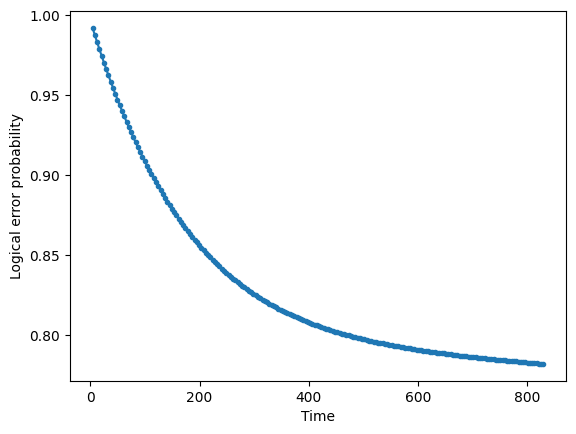

In [11]:
fig, ax = plt.subplots()
ax.plot(time, logic, marker=".", label="qubit correction")

ax.set_xlabel("Time")
ax.set_ylabel("Logical error probability")